<a href="https://colab.research.google.com/github/cwilches/DS_ClaudiaWilches/blob/main/ProyectoDS_Partel_WilchesSerrano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Presentación del proyecto**

**Abstracto**

El abandono de clientes (Churn) representa uno de los mayores desafíos estratégicos para las entidades financieras, impactando negativamente en el Lifetime Value y en la eficiencia de los costos de adquisición. Los clientes que finalizan su relación contractual no solo reducen la base de activos bajo administración, sino que representan una pérdida de oportunidades de cross-selling y crecimiento orgánico. Ante esta problemática, se requiere comprender los determinantes del comportamiento del usuario para transitar hacia una gestión basada en datos.

El presente reporte realiza un análisis exploratorio exhaustivo (EDA) con el fin de identificar patrones de comportamiento y características distintivas del segmento que abandona el banco. Mediante la limpieza de datos, el analisis univariado, el analisis multivariado y la visualización de distribuciones, se han formulado hipótesis de investigación orientadas a validar estadísticamente si variables como el saldo, la inactividad y la diversificación de productos guardan una relación significativa con el evento de abandono. Este estudio sienta las bases analíticas necesarias para una futura etapa de modelado predictivo, permitiendo a la entidad diagnosticar el estado actual de su cartera y orientar esfuerzos de retención hacia los segmentos de mayor riesgo.

# **Lectura de datos**

**Librerias necesarias para el analisis de datos**

In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

**Configuración del entorno**

In [63]:
# Configuraciones opcionales para mejor visualización
sns.set_theme(style="whitegrid") # Establece un tema estético para los gráficos
plt.rcParams['figure.figsize'] = (12, 6) # Establece un tamaño de figura por defecto

**Lectura del dataset**

https://raw.githubusercontent.com/cwilches/DS_ClaudiaWilches/refs/heads/main/Customer-Churn-Records.csv

In [64]:
rawgit='https://raw.githubusercontent.com/cwilches/DS_ClaudiaWilches/refs/heads/main/Customer-Churn-Records.csv'

In [65]:
df=pd.read_csv(rawgit)

In [66]:
print("Dimensiones (filas, columnas):", df.shape) # Salida: (5, 3)
print("Número de filas:", len(df))             # Salida: 5
print("Número de columnas:", len(df.columns))   # Salida: 3
print("Total de elementos:", df.size)          # Salida: 15


Dimensiones (filas, columnas): (10000, 18)
Número de filas: 10000
Número de columnas: 18
Total de elementos: 180000


**Análisis inicial del dataset**

In [67]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

**Descripción de variables**

In [69]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='object')

**RowNumber:** Indice secuencial de la fila en el dataset original.

**CustomerID:** Identificador único del cliente asignado por el banco.

**Surname:** Apellido del cliente.

**CreditScore:** Puntaje crediticio del cliente; a mayor valor, menor riesgo percibido.

**Geography:** Ubicación geográfica del cliente (Francia, España, Alemania).

**Gender:** Género del cliente.

**Age:** Edad del cliente; variable crítica que suele correlacionar con la estabilidad financiera.

**Tenure:** Tiempo (en años) que el cliente lleva vinculado con la entidad.

**Balance:** Saldo actual en la cuenta; indicador clave de actividad transaccional.

**NumOfProducts:** Cantidad de productos bancarios contratados (ej. tarjetas, préstamos, cuentas).

**HasCrCard:** Variable binaria que indica si el cliente posee tarjeta de crédito.

**IsActiveMember:** Variable binaria que identifica si el cliente ha realizado transacciones recientes (actividad).

**EstimatedSalary:** Salario anual estimado del cliente.

**Exited:** Variable binaria (1 = el cliente abandonó el banco, 0 = se mantiene).

**Complain:** Indicador de si el cliente ha presentado una queja formal.

**Satisfaction Score:**Escala ordinal (1-5) que mide el nivel de conformidad del cliente con el servicio.

**Card Type:** Categoría de la tarjeta de crédito del cliente

**Point Earned:** Puntos de lealtad acumulados por el uso de servicios bancarios.



# **Análisis Exploratorio de datos**

# **Data Wrangling - Limpieza y transformación de datos**

**Haciendo copia del dataset**

In [70]:
dfc=df.copy()

**Eliminando variables**

In [71]:
dfc.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)
dfc.head(2)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456


**NOTA:** Se ha procedido a la eliminación de la columna RowNumber, al ser redundante con el índice de la estructura de datos. Asimismo, se han excluido las variables CustomerID y Surname con el objetivo de garantizar la anonimización de la información, además de considerar que carecen de relevancia para el análisis del comportamiento de abandono (churn)."

**Valores duplicados**

In [72]:
dfc.duplicated().sum()

np.int64(0)

**Valores nulos**

In [73]:
dfc.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


# **VISUALIZACIÓN DE DATOS**

**Análisis univariado**

**Distribución**

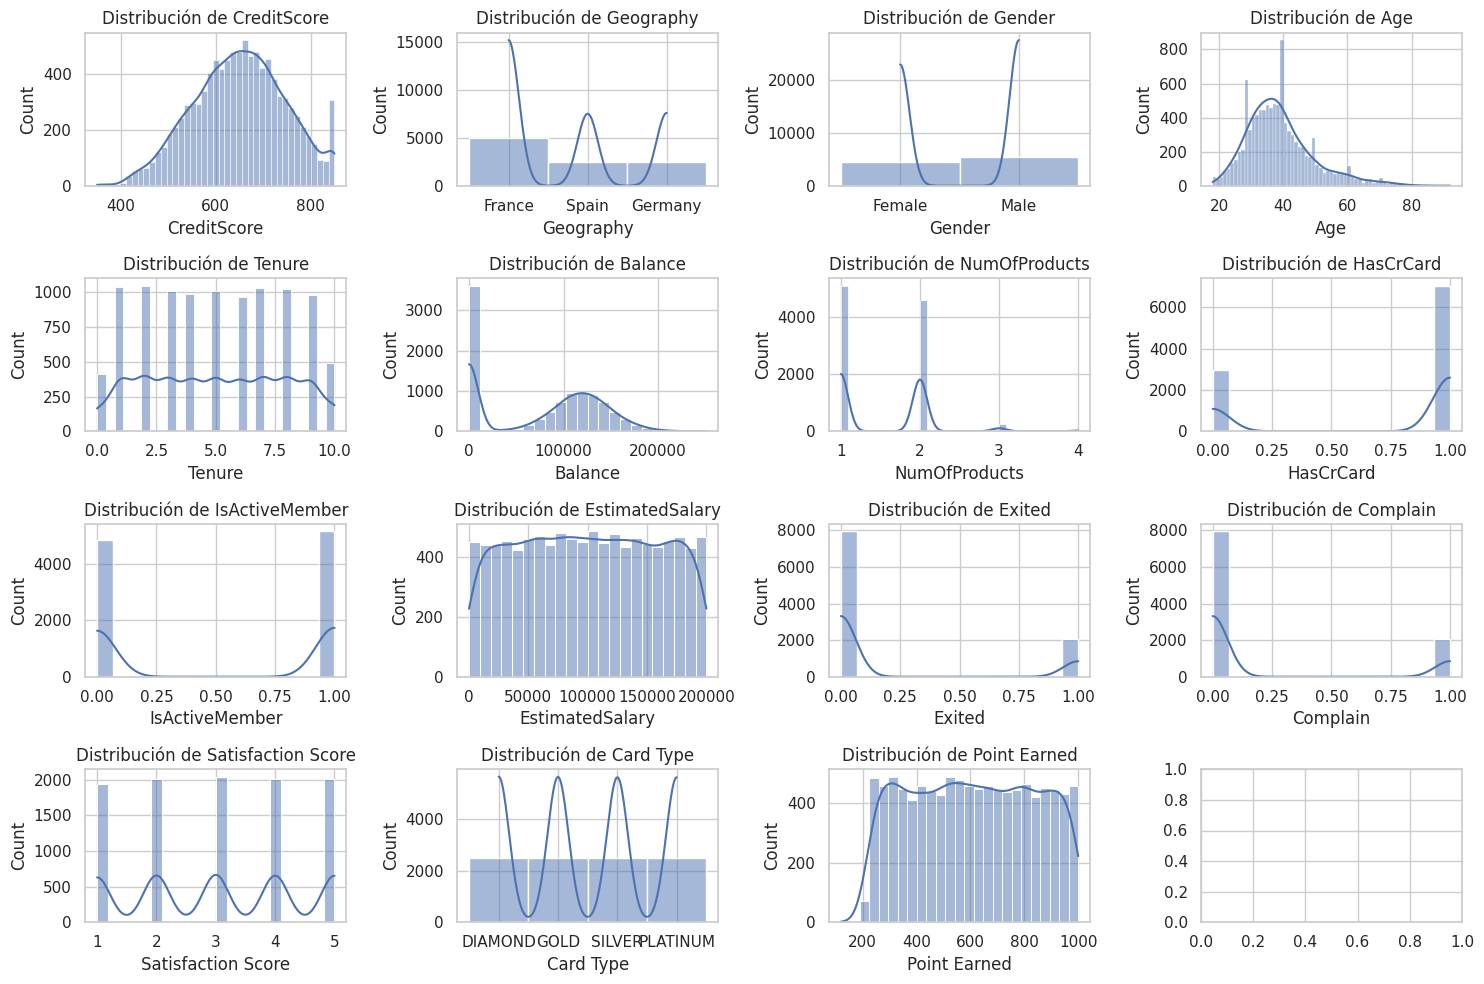

In [74]:
variables = dfc.columns

columns = 4
rows = 4

fig, axes = plt.subplots(rows, columns, figsize=(15,10))

for i in range(rows):
  for j in range(columns):
    idx=i*columns+j

    if idx<len(variables):
      nombre=variables[idx]
      sns.histplot(dfc[nombre],ax=axes[i,j],kde=True)
      axes[i,j].set_title(f"Distribución de {nombre}")

plt.tight_layout()
plt.show()

**Observaciones:**

* El conjunto de datos presenta un desbalanceo, con más casos de usuarios no abandonan (Exited = 0) que usuarios abandonan (Exited = 1)

* De este conjunto de gráficos podemos identificar que algunas de las variables tienen una distribución asimétrica (Age, Creditscore), otras tienen una distribución uniforme (SatisfactionScore, Point Earned, Card Type), además de que al parecer algunos valores presetan valores extremos (Balance,Age,CreditScore).

In [75]:
dfc_numerical = dfc.select_dtypes(include='number')

In [76]:
variables_num = dfc_numerical.columns

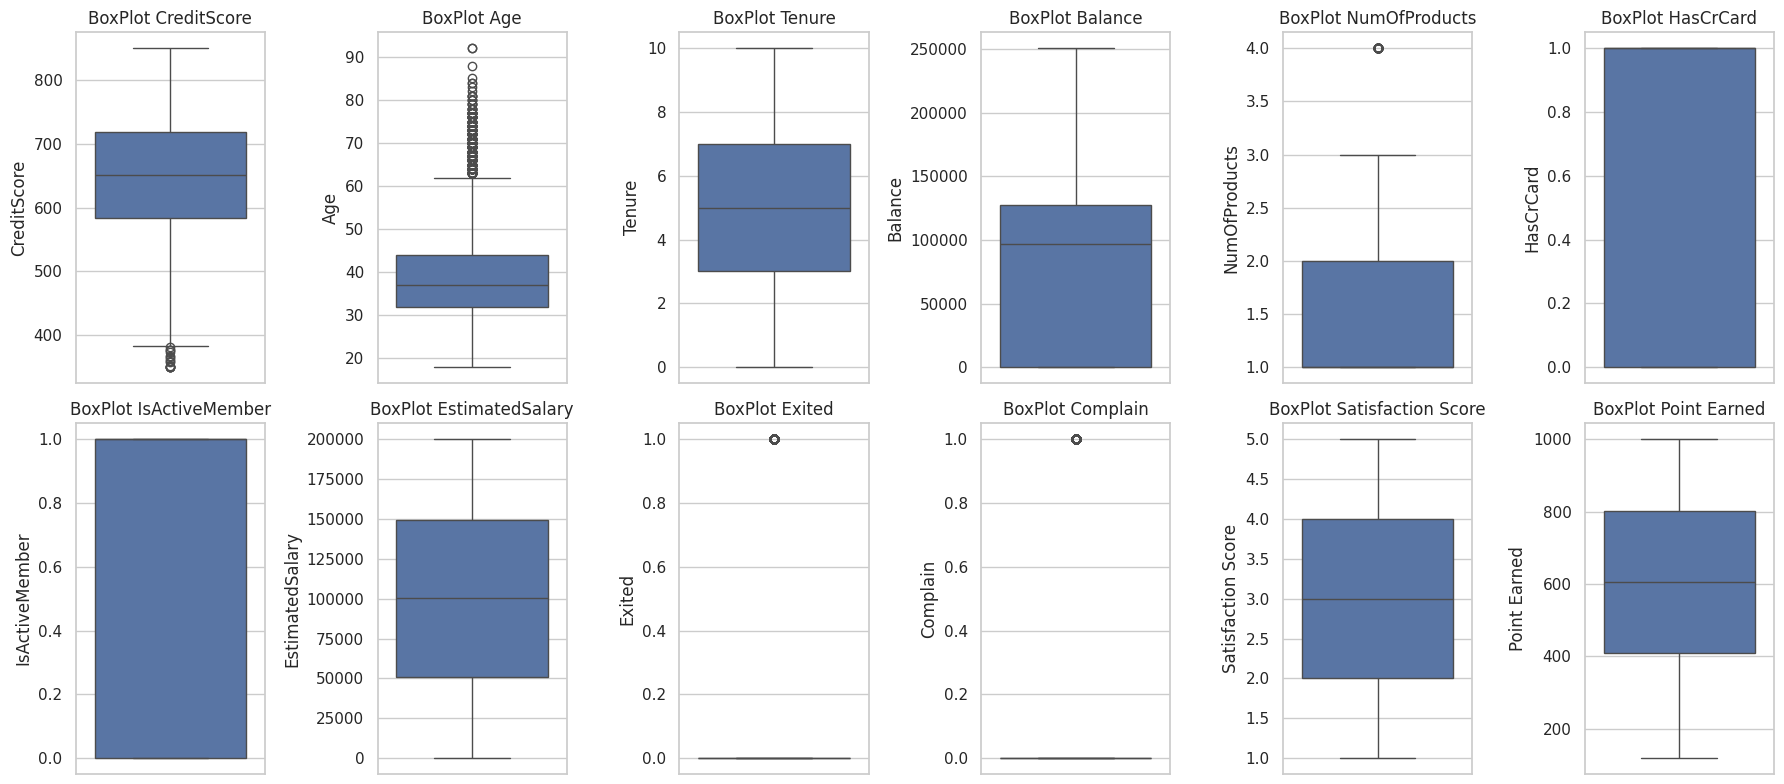

In [77]:

columns = 6
rows = 2

fig, axes = plt.subplots(rows, columns, figsize=(18,8))

for i in range(rows):
  for j in range(columns):
    idx=i*columns+j

    if idx<len(variables_num):
      nombre=variables_num[idx]
      sns.boxplot(dfc[nombre], ax=axes[i,j])
      axes[i,j].set_title(f"BoxPlot {nombre}")

plt.tight_layout()
plt.show()

**Observaciones:**
* Existen usuarios con un credit Score muy bajo, se hace necesario analizar si son usuarios con alto riesgo crediticio o un error en la asignación de score del banco

* El Boxplot muestra una cantidad de outliers para la variable edad superando los 60 años

* Los usuarios se concentran en hasta 2 productos y muy pocos llegan a tener 3 o 4 productos con la institución.

* En cuanto al balance muchos usuarios mantienen sus cuentas vacias.

**Análisis bivariado**

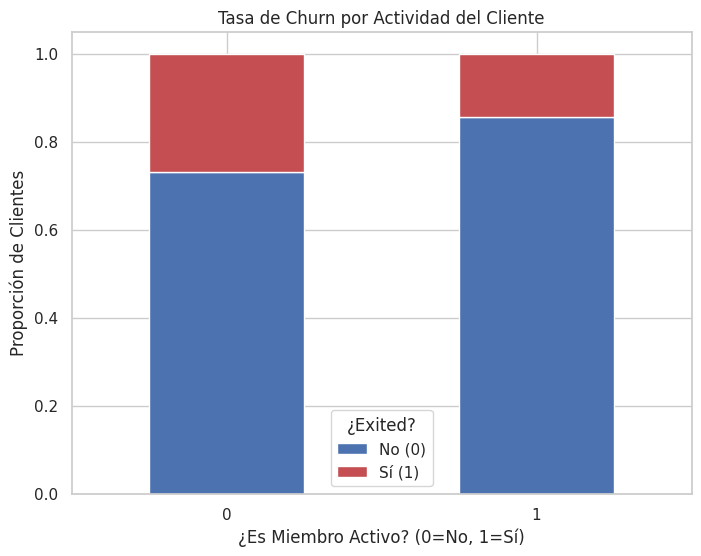

In [78]:
data_crosstab = pd.crosstab(dfc['IsActiveMember'], dfc['Exited'], normalize='index')

# Grafica
data_crosstab.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#4c72b0', '#c44e52'])

plt.title('Tasa de Churn por Actividad del Cliente')
plt.xlabel('¿Es Miembro Activo? (0=No, 1=Sí)')
plt.ylabel('Proporción de Clientes')
plt.legend(title='¿Exited?', labels=['No (0)', 'Sí (1)'])
plt.xticks(rotation=0)
plt.show()

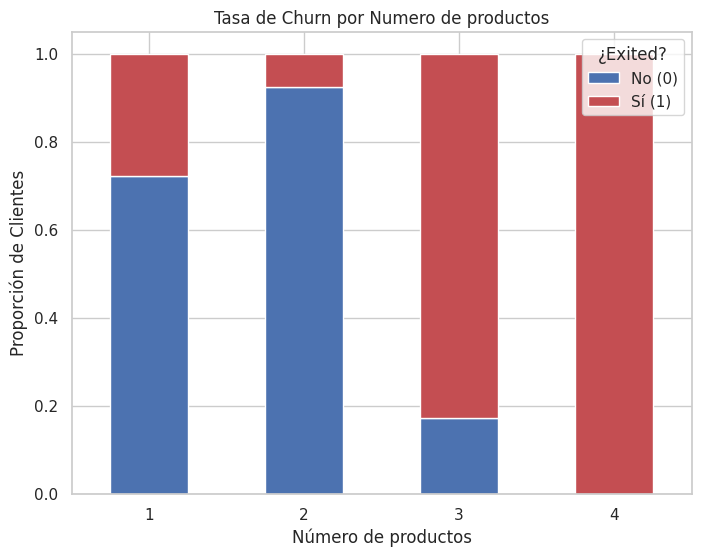

In [79]:
data_crosstab = pd.crosstab(dfc['NumOfProducts'], dfc['Exited'], normalize='index')

# Grafica
data_crosstab.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#4c72b0', '#c44e52'])

plt.title('Tasa de Churn por Numero de productos')
plt.xlabel('Número de productos')
plt.ylabel('Proporción de Clientes')
plt.legend(title='¿Exited?', labels=['No (0)', 'Sí (1)'])
plt.xticks(rotation=0)
plt.show()

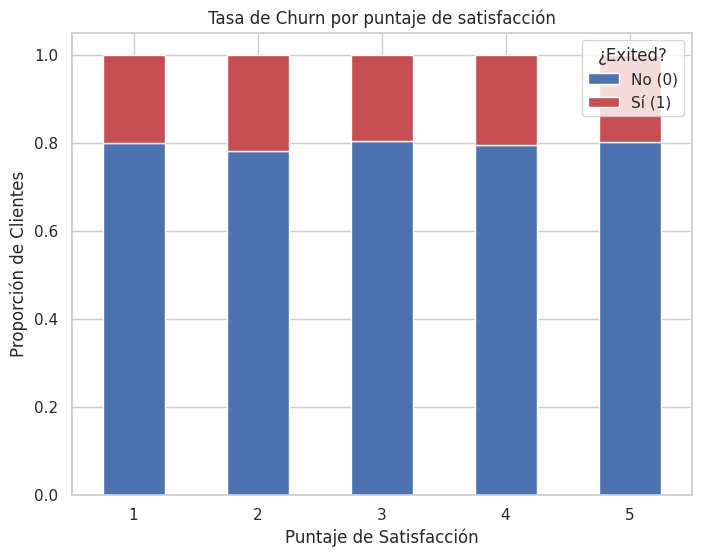

In [80]:
data_crosstab = pd.crosstab(dfc['Satisfaction Score'], dfc['Exited'], normalize='index')

# Grafica
data_crosstab.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#4c72b0', '#c44e52'])

plt.title('Tasa de Churn por puntaje de satisfacción')
plt.xlabel('Puntaje de Satisfacción')
plt.ylabel('Proporción de Clientes')
plt.legend(title='¿Exited?', labels=['No (0)', 'Sí (1)'])
plt.xticks(rotation=0)
plt.show()

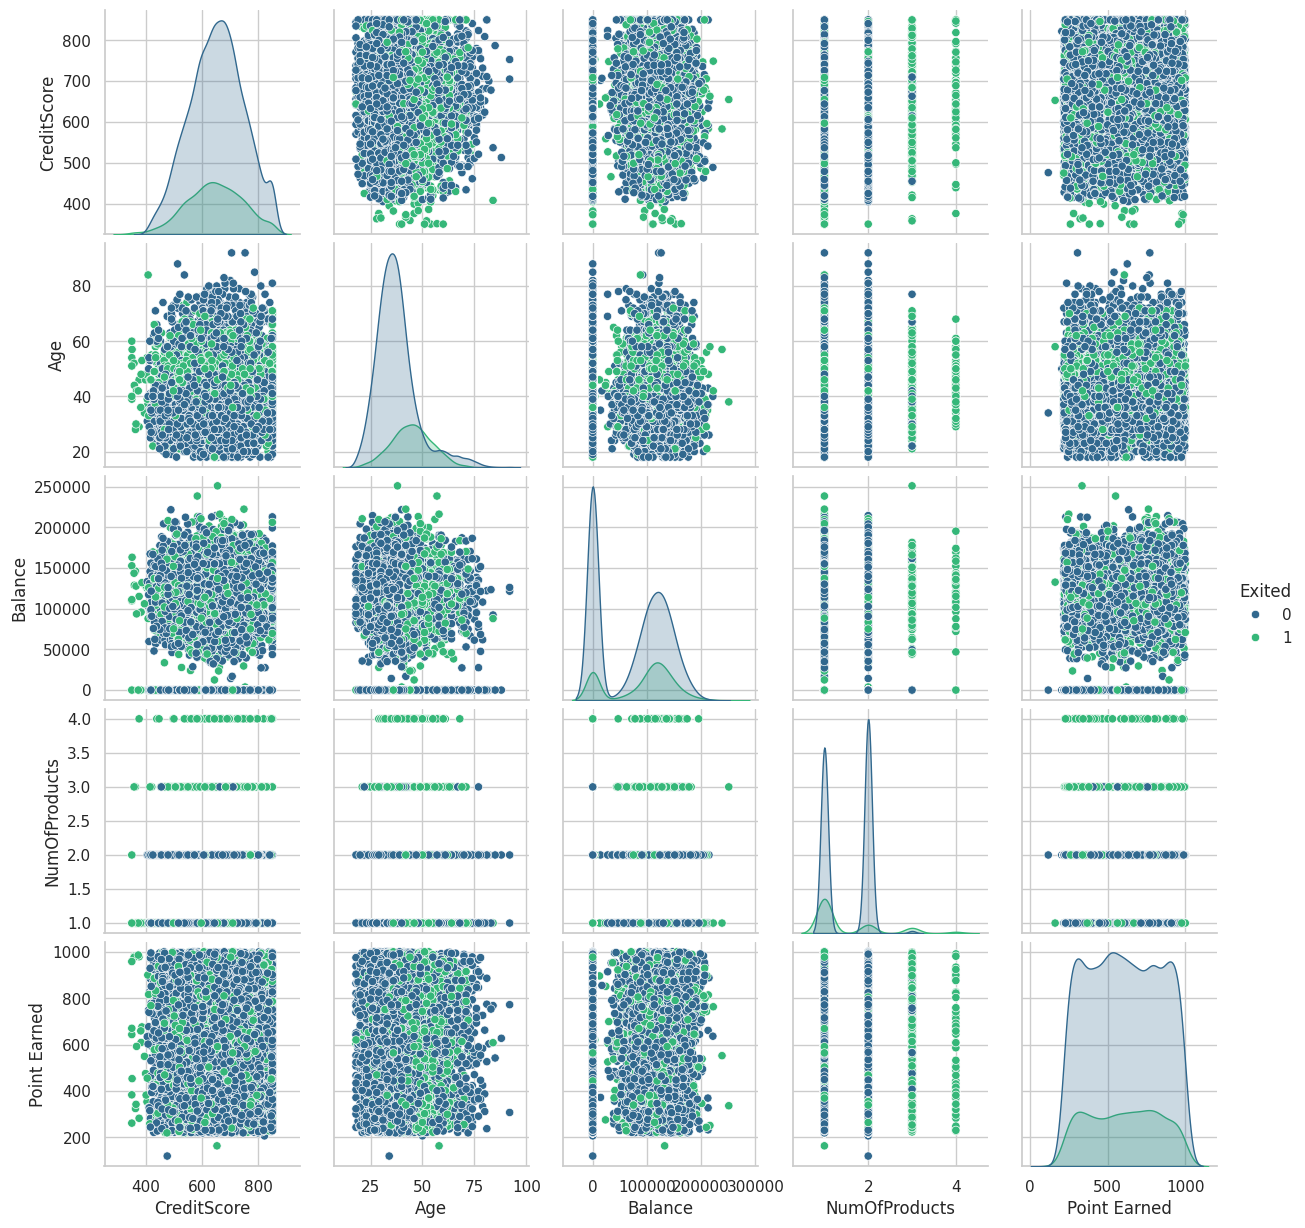

In [81]:
cols_analisis = ['CreditScore','Age','Balance','NumOfProducts','Point Earned','Exited']
#['CreditScore', 'Age', 'Balance', 'NumOfProducts','Exited']
sns.pairplot(dfc[cols_analisis], hue='Exited', palette='viridis', diag_kind='kde')
plt.show()

**Obervaciones:**

Mediante el analisis bivariado se logran identificar ciertas caracteristicas:
* Un grupo de usuarios con mas de 2 productos concentran los usaurios que abandonan.
* Una concentración de usuarios en el rango de edad de los 50.
* Las variables que presentaron un distribución uniforme en el analisis previo no presentan un patron claro frente a los usuarios que abandonan.

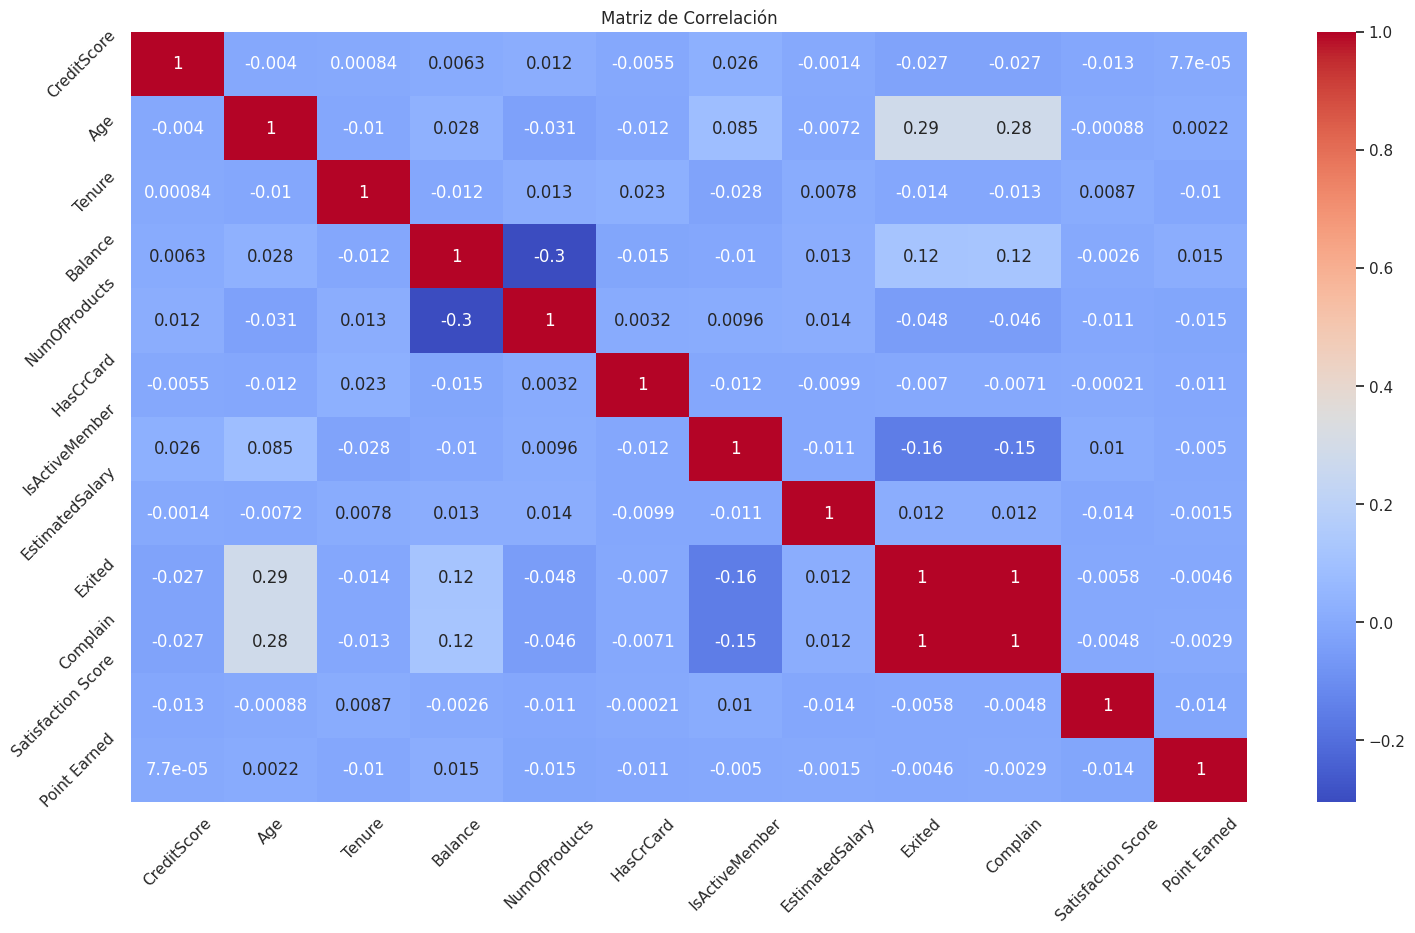

In [82]:
# Matriz de correlación
correlation_matrix = dfc_numerical.corr()

# Mapa de calor
plt.figure(figsize=(18,10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.show()

In [83]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00
CustomerId,10000.0,15690940.57,71936.19,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00
CreditScore,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
NumOfProducts,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
HasCrCard,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
IsActiveMember,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48


**Observaciones:**

A primera vista con el resumen estadistico del dataset confirma en el analisis grafico realizado previamente:

* La variable Exited tiene una media de 0,20 lo que explica el desbalanceo de los datos.

* El 25% de los usuarios tienen un saldo 0 en sus cuentas.

* Las variables complain y Exited tienen una relación perfecta lo que puede indicar que es una replica y puede mostrar patrones sesgados.

* La edad promedio es de 39 años.

* El salario promedio ronda los 100.000

* el 52% de los usuarios son usuarios activos.



**Preguntas/Hipótesis a Resolver mediante el Análisis de Datos**

Se plantean las siguientes preguntas o hipotesis:


---
**Pregunta:** ¿Los clientes inactivos abandonan más que los activos?

**H0 (Hipótesis Nula):** La tasa de abandono es independiente del estatus de actividad.

**H1 (Hipótesis Alternativa):** Existe una mayor tasa de abandono entre los miembros inactivos (IsActiveMember = 0).



---

**Pregunta:** ¿Existe una diferencia entre los cleintes que abandonan o no la institución?

**H0 (Hipótesis Nula):** No hay diferencia entre los grupos (el Churn es independiente).

**H1 (Hipótesis Alternativa):** Hay una diferencia significativa (el Churn está influenciado por la variable).


---

**Pregunta:** ¿Los clientes con saldo cero tienen mayor riesgo de abandonar?

**H0 (Hipótesis Nula):** El saldo promedio no difiere entre los clientes que se quedan y los que se van.

**H1 (Hipótesis Alternativa):** Los clientes con saldo cero tienen una probabilidad de abandono significativamente mayor que aquellos con saldos positivos.